<a href="https://colab.research.google.com/github/NguyenAnhDo165/CNN-Exercise/blob/main/B%C3%A0i%20t%E1%BA%ADp%20Nh%E1%BA%ADn%20di%E1%BB%87n%20Hoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing import image_dataset_from_directory
import numpy as np
import os

# Tải dataset
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

# Đường dẫn tới thư mục chứa các class hoa
dataset_path = os.path.join(path, "flowers")

print("Dataset path:", dataset_path)
print("Các thư mục class:", os.listdir(dataset_path))

Using Colab cache for faster access to the 'flowers-recognition' dataset.
Dataset path: /kaggle/input/flowers-recognition/flowers
Các thư mục class: ['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']


In [ ]:
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    interpolation='bicubic'
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    interpolation='bicubic'
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Số lớp:", num_classes)

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.
Class names: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Số lớp: 5


In [ ]:
def get_images_and_labels(dataset):
    all_images = []
    all_labels = []

    for images, labels in dataset:
        all_images.append(images.numpy())
        all_labels.append(labels.numpy())

    return np.concatenate(all_images), np.concatenate(all_labels)

x_train_raw, y_train_raw = get_images_and_labels(train_ds)
x_test_raw, y_test_raw = get_images_and_labels(val_ds)

x_train = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0

y_train = to_categorical(y_train_raw, num_classes=num_classes)
y_test = to_categorical(y_test_raw, num_classes=num_classes)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3454, 180, 180, 3)
(3454, 5)
(863, 180, 180, 3)
(863, 5)


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Input, Dropout

model = Sequential([
    Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    Conv2D(32, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation = "relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation = "relu"),
    Dropout(0.5),
    Dense(num_classes, activation = "softmax")
])

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test)
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.4224 - loss: 1.3322 - val_accuracy: 0.5075 - val_loss: 1.1762
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.5533 - loss: 1.0966 - val_accuracy: 0.5829 - val_loss: 1.0901
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.6126 - loss: 0.9779 - val_accuracy: 0.6489 - val_loss: 0.9042
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6783 - loss: 0.8340 - val_accuracy: 0.6489 - val_loss: 0.8653
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.7299 - loss: 0.7216 - val_accuracy: 0.6732 - val_loss: 0.8977
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7788 - loss: 0.5861 - val_accuracy: 0.6721 - val_loss: 0.9329
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8277 - loss: 0.4607 - val_accuracy: 0.6628 - val_loss: 0.9711
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8694 - loss: 0.3641 - val_ac

In [ ]:
model.save("trainFlowers.h5")

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('trainFlowers.h5')

# Print a summary of the loaded model to verify
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,623 (25.36 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

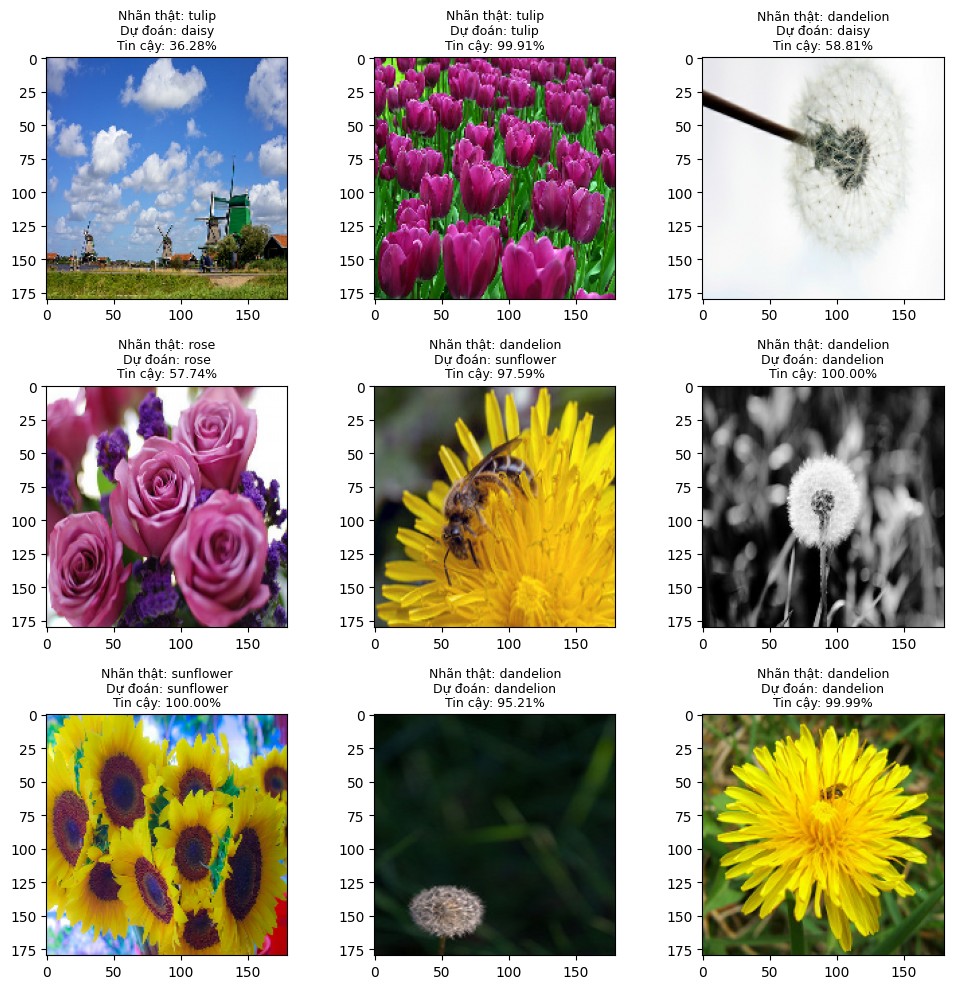

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

indices = np.random.choice(len(x_test), 9, replace=False)

plt.figure(figsize=(10, 10))

for i, index in enumerate(indices):
    img = x_test[index]

    true_label_index = np.argmax(y_test[index])
    true_label = class_names[true_label_index]

    prediction = loaded_model.predict(
        img.reshape(1, IMG_HEIGHT, IMG_WIDTH, 3),
        verbose=0
    )

    predicted_label_index = np.argmax(prediction)
    predicted_label = class_names[predicted_label_index]
    confidence = np.max(prediction) * 100

    plt.subplot(3, 3, i + 1)

    # Chặn giá trị ảnh về đúng khoảng 0 đến 1 để không bị Warning
    plt.imshow(np.clip(img, 0, 1))

    plt.title(
        f"Nhãn thật: {true_label}\nDự đoán: {predicted_label}\nTin cậy: {confidence:.2f}%",
        fontsize=9
    )

plt.tight_layout()
plt.show()